In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
import joblib
from datetime import datetime, timedelta

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# TensorFlow/Keras imports
try:
    from tensorflow import keras
    from tensorflow.keras.models import Sequential, load_model
    from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    KERAS_AVAILABLE = True
except ImportError:
    print("Warning: TensorFlow not available. Deep learning models won't work.")
    KERAS_AVAILABLE = False

In [37]:
class RealtimeTrafficPredictor:
    """
    Real-time Traffic Predictor for Regression (Forecasting)
    Modified to work with: segment_id, timestamp_ist, speed_current_kmph, 
                          speed_freeflow_kmph, congestion_index
    """
    
    def __init__(self, model_path='models/regression/'):
        self.model_path = model_path
        self.lookback =  60 #1 hour of history
        self.forecast_steps = 10  # Predict next interval
        
        # Create directories
        os.makedirs(self.model_path, exist_ok=True)
        os.makedirs('plots', exist_ok=True)
        
        self.scaler = MinMaxScaler()
        self.models = {}
        
        print(f'✓ RealtimeTrafficPredictor initialized')
        print(f'  Model path: {self.model_path}')
        print(f'  Lookback: {self.lookback} intervals')
    
    
    def load_data(self, df_or_path):
        """
        Load data from DataFrame or Parquet file
        
        Expected columns:
        - segment_id (or road_id)
        - timestamp_ist (or window_start)
        - speed_current_kmph (or avg_speed)
        - speed_freeflow_kmph
        - congestion_index (or avg_congestion_index)
        """
        if isinstance(df_or_path, str):
            # Load from file
            if df_or_path.endswith('.parquet'):
                df = pd.read_parquet(df_or_path)
            elif df_or_path.endswith('.csv'):
                df = pd.read_csv(df_or_path)
            else:
                raise ValueError("File must be .parquet or .csv")
            print(f"✓ Loaded {len(df)} records from {df_or_path}")
        else:
            # Already a DataFrame
            df = df_or_path.copy()
            print(f"✓ Loaded {len(df)} records from DataFrame")
        
        # Normalize column names
        column_mapping = {
            'road_id': 'segment_id',
            'window_start': 'timestamp_ist',
            'avg_speed': 'speed_current_kmph',
            'avg_congestion_index': 'congestion_index'
        }
        
        for old_col, new_col in column_mapping.items():
            if old_col in df.columns and new_col not in df.columns:
                df = df.rename(columns={old_col: new_col})
        
        # Validate required columns
        required_cols = ['segment_id', 'timestamp_ist', 'speed_current_kmph', 'congestion_index']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        return df
    
    
    def preprocess_data(self, df, segment_id=None):
        """Preprocess the real-time data"""
        df = df.copy()
        df['timestamp_ist'] = pd.to_datetime(df['timestamp_ist'])
        
        # Filter by segment if specified
        if segment_id:
            df = df[df['segment_id'] == segment_id].copy()
            print(f'✓ Filtered to segment_id: {segment_id}, {len(df)} records')
        
        # Sort by timestamp
        df = df.sort_values('timestamp_ist').reset_index(drop=True)
        
        # Extract time features
        df['hour'] = df['timestamp_ist'].dt.hour
        df['minute'] = df['timestamp_ist'].dt.minute
        df['day_of_week'] = df['timestamp_ist'].dt.dayofweek
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
        df['is_rush_hour'] = ((df['hour'].between(7, 10)) | 
                              (df['hour'].between(17, 20))).astype(int)
        
        # Cyclical time features
        df['time_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['time_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        
        return df
    
    
    def create_features(self, df):
        """Create additional features for prediction"""
        # Speed change rate
        df['speed_change'] = df['speed_current_kmph'].diff()
        df['congestion_change'] = df['congestion_index'].diff()
        
        # Rolling statistics (past 3, 6, and 12 periods)
        for window in [3, 6, 12]:
            df[f'speed_rolling_mean_{window}'] = df['speed_current_kmph'].rolling(
                window=window, min_periods=1).mean()
            df[f'speed_rolling_std_{window}'] = df['speed_current_kmph'].rolling(
                window=window, min_periods=1).std().fillna(0)
            df[f'congestion_rolling_mean_{window}'] = df['congestion_index'].rolling(
                window=window, min_periods=1).mean()
            df[f'congestion_rolling_std_{window}'] = df['congestion_index'].rolling(
                window=window, min_periods=1).std().fillna(0)
        
        # Fill NaN values
        df = df.fillna(method='bfill').fillna(method='ffill')
        
        return df
    
    
    def create_sequences(self, data, feature_cols, target_col):
        """Create sequences for time series prediction"""
        X, y = [], []
        
        for i in range(len(data) - self.lookback):
            X.append(data[feature_cols].iloc[i:i+self.lookback].values)
            y.append(data[target_col].iloc[i+self.lookback])
        
        return np.array(X), np.array(y)
    
    
    def prepare_data(self, df, test_size=0.2):
        """Prepare data for training"""
        # Define feature columns
        feature_cols = [
            'speed_current_kmph', 'congestion_index', 
            'hour', 'minute', 'day_of_week', 'is_weekend', 'is_rush_hour',
            'time_sin', 'time_cos', 'day_sin', 'day_cos',
            'speed_change', 'congestion_change'
        ]
        
        # Add rolling features
        rolling_cols = [col for col in df.columns if 'rolling' in col]
        feature_cols.extend(rolling_cols)
        
        # Ensure all feature columns exist
        feature_cols = [col for col in feature_cols if col in df.columns]
        
        target_col = 'congestion_index'
        
        # Scale the features
        df_scaled = df.copy()
        df_scaled[feature_cols] = self.scaler.fit_transform(df[feature_cols])
        
        # Create sequences
        X, y = self.create_sequences(df_scaled, feature_cols, target_col)
        
        # Split into train and test
        split_idx = int(len(X) * (1 - test_size))
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        
        print(f"\n✓ Data Prepared:")
        print(f"  Training samples: {len(X_train)}")
        print(f"  Testing samples: {len(X_test)}")
        print(f"  Features: {len(feature_cols)}")
        print(f"  Sequence length: {self.lookback}")
        
        return X_train, X_test, y_train, y_test, feature_cols
    
    
    # ==================== MODEL BUILDING ====================
    
    def build_lstm_model(self, input_shape):
        """Build LSTM Model"""
        if not KERAS_AVAILABLE:
            raise ImportError("TensorFlow/Keras not available")
        
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    def build_gru_model(self, input_shape):
        """Build GRU model"""
        if not KERAS_AVAILABLE:
            raise ImportError("TensorFlow/Keras not available")
        
        model = Sequential([
            GRU(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            GRU(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    def build_lstm_gru_model(self, input_shape):
        """Build LSTM+GRU hybrid model"""
        if not KERAS_AVAILABLE:
            raise ImportError("TensorFlow/Keras not available")
        
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            GRU(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    def build_gru_lstm_model(self, input_shape):
        """Build GRU+LSTM hybrid model"""
        if not KERAS_AVAILABLE:
            raise ImportError("TensorFlow/Keras not available")
        
        model = Sequential([
            GRU(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    # ==================== MODEL TRAINING ====================
    
    def train_deep_learning_model(self, model, model_name, X_train, X_test, y_train, y_test):
        """Train deep learning models (LSTM, GRU, etc.)"""
        print(f"\n{'='*60}")
        print(f"Training {model_name} Model")
        print('='*60)
        
        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=15, 
                                   restore_best_weights=True, verbose=1)
        checkpoint = ModelCheckpoint(
            os.path.join(self.model_path, f'{model_name.lower()}_best.keras'),
            monitor='val_loss',
            save_best_only=True,
            verbose=0        )
        
        # Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=100,
            batch_size=32,
            callbacks=[early_stop, checkpoint],
            verbose=1
        )
        
        # Make predictions
        y_pred_train = model.predict(X_train, verbose=0).flatten()
        y_pred_test = model.predict(X_test, verbose=0).flatten()
        
        # Calculate metrics
        train_mae = mean_absolute_error(y_train, y_pred_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_mae = mean_absolute_error(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_r2 = r2_score(y_test, y_pred_test)
        
        print(f"\n✓ {model_name} Results:")
        print(f"  Train MAE: {train_mae:.4f}, Train RMSE: {train_rmse:.4f}")
        print(f"  Test MAE: {test_mae:.4f}, Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
        
        # Save model
        model.save(os.path.join(self.model_path, f'{model_name.lower()}.keras'))
        print(f"  Model saved to {self.model_path}/{model_name.lower()}.keras")
        
        return model, history, y_pred_test
    
    
    def train_random_forest(self, X_train, X_test, y_train, y_test):
        """Train Random Forest Regressor"""
        print(f"\n{'='*60}")
        print("Training Random Forest Model")
        print('='*60)
        
        # Reshape data for Random Forest (flatten sequences)
        X_train_rf = X_train.reshape(X_train.shape[0], -1)
        X_test_rf = X_test.reshape(X_test.shape[0], -1)
        
        # Train model
        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
        
        model.fit(X_train_rf, y_train)
        
        # Make predictions
        y_pred_train = model.predict(X_train_rf)
        y_pred_test = model.predict(X_test_rf)
        
        # Calculate metrics
        train_mae = mean_absolute_error(y_train, y_pred_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_mae = mean_absolute_error(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_r2 = r2_score(y_test, y_pred_test)
        
        print(f"\n✓ Random Forest Results:")
        print(f"  Train MAE: {train_mae:.4f}, Train RMSE: {train_rmse:.4f}")
        print(f"  Test MAE: {test_mae:.4f}, Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
        
        # Save model
        joblib.dump(model, os.path.join(self.model_path, 'random_forest.joblib'))
        print(f"  Model saved to {self.model_path}/random_forest.joblib")
        
        return model, y_pred_test
    
    
    def train_all_models(self, df, segment_id=None):
        """Train all models and save them"""
        df = self.load_data(df)
        df = self.preprocess_data(df, segment_id)
        df = self.create_features(df)
        
        # Prepare data
        X_train, X_test, y_train, y_test, feature_cols = self.prepare_data(df)
        
        # Store results
        results = {}
        predictions = {}
        
        if KERAS_AVAILABLE:
            # Train LSTM
            lstm_model = self.build_lstm_model((X_train.shape[1], X_train.shape[2]))
            lstm_trained, lstm_history, lstm_pred = self.train_deep_learning_model(
                lstm_model, 'LSTM', X_train, X_test, y_train, y_test
            )
            results['LSTM'] = lstm_history
            predictions['LSTM'] = lstm_pred
            self.models['LSTM'] = lstm_trained
            
            # Train GRU
            gru_model = self.build_gru_model((X_train.shape[1], X_train.shape[2]))
            gru_trained, gru_history, gru_pred = self.train_deep_learning_model(
                gru_model, 'GRU', X_train, X_test, y_train, y_test
            )
            results['GRU'] = gru_history
            predictions['GRU'] = gru_pred
            self.models['GRU'] = gru_trained
            
            # Train LSTM+GRU
            lstm_gru_model = self.build_lstm_gru_model((X_train.shape[1], X_train.shape[2]))
            lstm_gru_trained, lstm_gru_history, lstm_gru_pred = self.train_deep_learning_model(
                lstm_gru_model, 'LSTM_GRU', X_train, X_test, y_train, y_test
            )
            results['LSTM_GRU'] = lstm_gru_history
            predictions['LSTM_GRU'] = lstm_gru_pred
            self.models['LSTM_GRU'] = lstm_gru_trained
            
            # Train GRU+LSTM
            gru_lstm_model = self.build_gru_lstm_model((X_train.shape[1], X_train.shape[2]))
            gru_lstm_trained, gru_lstm_history, gru_lstm_pred = self.train_deep_learning_model(
                gru_lstm_model, 'GRU_LSTM', X_train, X_test, y_train, y_test
            )
            results['GRU_LSTM'] = gru_lstm_history
            predictions['GRU_LSTM'] = gru_lstm_pred
            self.models['GRU_LSTM'] = gru_lstm_trained
        else:
            print("\nSkipping deep learning models (TensorFlow not available)")
        
        # Train Random Forest
        rf_trained, rf_pred = self.train_random_forest(X_train, X_test, y_train, y_test)
        predictions['Random_Forest'] = rf_pred
        self.models['Random_Forest'] = rf_trained
        
        # Save scaler and feature columns
        joblib.dump(self.scaler, os.path.join(self.model_path, 'scaler.joblib'))
        joblib.dump(feature_cols, os.path.join(self.model_path, 'feature_cols.joblib'))
        print(f"\n✓ Saved scaler and feature columns")
        
        # Plot results
        self.plot_predictions(y_test, predictions, df, segment_id)
        
        return results, predictions
    
    
    def plot_predictions(self, y_test, predictions, df, segment_id):
        """Plot actual vs predicted values"""
        n_models = len(predictions)
        ncols = 2
        nrows = (n_models + 1) // 2
        
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
        fig.suptitle(f'Traffic Congestion Predictions - Segment: {segment_id}', 
                     fontsize=16, fontweight='bold')
        
        if nrows == 1:
            axes = axes.reshape(1, -1)
        axes = axes.flatten()
        
        # Get timestamps for test data
        test_start_idx = len(df) - len(y_test)
        timestamps = df['timestamp_ist'].iloc[test_start_idx:].values
        
        colors = {
            'LSTM': '#1f77b4',
            'GRU': '#ff7f0e',
            'LSTM_GRU': '#2ca02c',
            'GRU_LSTM': '#d62728',
            'Random_Forest': '#9467bd'
        }
        
        for idx, (model_name, y_pred) in enumerate(predictions.items()):
            if idx >= len(axes):
                break
            
            ax = axes[idx]
            
            # Plot actual data
            ax.plot(timestamps, y_test, label='Actual', color='black', 
                   linewidth=2, alpha=0.8, marker='o', markersize=3)
            
            # Plot predicted data
            ax.plot(timestamps, y_pred, label='Predicted', 
                   color=colors.get(model_name, '#999'), 
                   linewidth=2, alpha=0.6, linestyle='--', marker='s', markersize=3)
            
            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            # Styling
            ax.set_title(f'{model_name}\nMAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Timestamp', fontsize=10)
            ax.set_ylabel('Congestion Index', fontsize=10)
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(True, alpha=0.3, linestyle=':')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            
            # Shaded area
            ax.fill_between(timestamps, y_test, y_pred, alpha=0.2, 
                           color=colors.get(model_name, '#999'))
        
        # Hide extra subplots
        for idx in range(len(predictions), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plot_path = os.path.join('plots', 
                                f'predictions_{segment_id}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Plot saved to {plot_path}")
        plt.show()
    
    
    def predict_next_interval(self, df, segment_id, model_name='LSTM'):
        """
        Predict the next time interval using trained model
        
        Args:
            df: DataFrame or path to data file
            segment_id: Segment ID to predict for
            model_name: Model to use ('LSTM', 'GRU', 'LSTM_GRU', 'GRU_LSTM', 'Random_Forest')
        
        Returns:
            dict with prediction results
        """
        # Load data
        df = self.load_data(df)
        
        # Load model if not in memory
        if model_name not in self.models:
            if model_name == 'Random_Forest':
                model_file = os.path.join(self.model_path, 'random_forest.joblib')
                self.models[model_name] = joblib.load(model_file)
            else:
                if not KERAS_AVAILABLE:
                    raise ImportError("TensorFlow/Keras not available for deep learning models")
                model_file = os.path.join(self.model_path, f'{model_name.lower()}.keras')
                self.models[model_name] = load_model(model_file)
            print(f'✓ Loaded model: {model_name}')
        
        # Load scaler and feature columns
        self.scaler = joblib.load(os.path.join(self.model_path, 'scaler.joblib'))
        feature_cols = joblib.load(os.path.join(self.model_path, 'feature_cols.joblib'))
        
        # Preprocess data
        df = self.preprocess_data(df, segment_id)
        df = self.create_features(df)
        
        # Get last lookback intervals
        latest_data = df.tail(self.lookback).copy()
        
        if len(latest_data) < self.lookback:
            raise ValueError(f"Not enough data. Need at least {self.lookback} records, got {len(latest_data)}")
        
        # Scale features
        latest_scaled = self.scaler.transform(latest_data[feature_cols])
        
        # Prepare input
        X_pred = latest_scaled.reshape(1, self.lookback, len(feature_cols))
        
        # Make prediction
        if model_name == 'Random_Forest':
            X_pred_rf = X_pred.reshape(1, -1)
            prediction = self.models[model_name].predict(X_pred_rf)[0]
        else:
            prediction = self.models[model_name].predict(X_pred, verbose=0)[0][0]
        
        # Get prediction class
        pred_class = 'LOW' if prediction < 0.3 else ('MEDIUM' if prediction < 0.6 else 'HIGH')
        
        # Get next timestamp (assuming 5-minute intervals)
        last_timestamp = df['timestamp_ist'].iloc[-1]
        next_timestamp = last_timestamp + timedelta(minutes=5)
        
        # Current values
        current_congestion = float(df['congestion_index'].iloc[-1])
        current_speed = float(df['speed_current_kmph'].iloc[-1])
        
        # Trend
        trend = prediction - current_congestion
        trend_str = "⬆️ INCREASING" if trend > 0.05 else ("⬇️ DECREASING" if trend < -0.05 else "➡️ STABLE")
        
        result = {
            'segment_id': segment_id,
            'model': model_name,
            'predicted_timestamp': next_timestamp,
            'predicted_congestion_index': float(prediction),
            'predicted_class': pred_class,
            'current_congestion_index': current_congestion,
            'current_speed': current_speed,
            'last_update': last_timestamp,
            'trend': trend_str,
            'trend_value': float(trend)
        }
        
        return result
    
    
    def format_prediction(self, result):
        """Format prediction result for display"""
        print('\n' + '='*70)
        print('TRAFFIC PREDICTION RESULT')
        print('='*70)
        print(f'\n📍 Segment: {result["segment_id"]}')
        print(f'🤖 Model: {result["model"]}')
        print(f'\n⏰ Current Time: {result["last_update"]}')
        print(f'⏰ Forecast Time: {result["predicted_timestamp"]}')
        print(f'\n📊 Current State:')
        print(f'  Congestion Index: {result["current_congestion_index"]:.3f}')
        print(f'  Speed: {result["current_speed"]:.1f} km/h')
        print(f'\n📈 Prediction:')
        print(f'  Congestion Index: {result["predicted_congestion_index"]:.3f}')
        print(f'  Class: {result["predicted_class"]}')
        print(f'  Trend: {result["trend"]} ({result["trend_value"]:+.3f})')
        print('\n' + '='*70)

In [38]:
def load_all_parquet_files(directory_path):
    """
    Load all parquet files from a directory
    
    Args:
        directory_path: Path to directory containing parquet files
        
    Returns:
        Combined DataFrame from all parquet files
    """
    import glob
    
    print(f'\n📂 Loading parquet files from: {directory_path}')
    
    # Get all parquet files
    pattern = os.path.join(directory_path, '*.parquet')
    files = glob.glob(pattern)
    
    if not files:
        raise FileNotFoundError(f"No parquet files found in {directory_path}")
    
    print(f'   Found {len(files)} parquet files')
    
    # Load all files
    dfs = []
    for file in files:
        try:
            df = pd.read_parquet(file)
            dfs.append(df)
            print(f'   ✓ Loaded: {os.path.basename(file)} ({len(df)} records)')
        except Exception as e:
            print(f'   ✗ Error loading {os.path.basename(file)}: {e}')
    
    if not dfs:
        raise ValueError("No parquet files could be loaded")
    
    # Combine all DataFrames
    df_combined = pd.concat(dfs, ignore_index=True)
    
    # Remove duplicates
    if 'timestamp_ist' in df_combined.columns and 'segment_id' in df_combined.columns:
        df_combined = df_combined.drop_duplicates(
            subset=['segment_id', 'timestamp_ist'], 
            keep='last'
        ).reset_index(drop=True)
    
    print(f'\n✓ Combined dataset: {len(df_combined)} total records')
    print(f'  Segments: {df_combined["segment_id"].unique().tolist() if "segment_id" in df_combined.columns else "N/A"}')
    print(f'  Time range: {df_combined["timestamp_ist"].min()} to {df_combined["timestamp_ist"].max() if "timestamp_ist" in df_combined.columns else "N/A"}')
    
    return df_combined

In [39]:
def create_project_visualizations(predictor, df, predictions_dict, segment_id):
    """
    Create comprehensive visualizations for the entire project
    
    Args:
        predictor: RealtimeTrafficPredictor instance
        df: Input DataFrame
        predictions_dict: Dictionary of predictions from all models
        segment_id: Segment ID for the visualizations
    """
    print('\n' + '='*70)
    print('📊 CREATING PROJECT VISUALIZATIONS')
    print('='*70)
    
    # Create output directory
    viz_dir = 'plots'
    os.makedirs(viz_dir, exist_ok=True)
    
    # 1. Traffic Pattern Overview
    print('\n1️⃣  Creating traffic pattern overview...')
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Traffic Analysis Overview - {segment_id}', fontsize=16, fontweight='bold')
    
    df_seg = df[df['segment_id'] == segment_id].copy()
    df_seg['timestamp_ist'] = pd.to_datetime(df_seg['timestamp_ist'], errors='coerce')
    df_seg['hour'] = df_seg['timestamp_ist'].dt.hour
    
    # Congestion by hour
    hourly_congestion = df_seg.groupby('hour')['congestion_index'].agg(['mean', 'std'])
    axes[0, 0].bar(hourly_congestion.index, hourly_congestion['mean'], 
                   yerr=hourly_congestion['std'], alpha=0.7, color='#1f77b4', capsize=3)
    axes[0, 0].set_xlabel('Hour of Day', fontweight='bold')
    axes[0, 0].set_ylabel('Average Congestion Index', fontweight='bold')
    axes[0, 0].set_title('Hourly Congestion Pattern')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(y=0.3, color='green', linestyle='--', label='LOW threshold', alpha=0.5)
    axes[0, 0].axhline(y=0.6, color='red', linestyle='--', label='HIGH threshold', alpha=0.5)
    axes[0, 0].legend()
    
    # Speed by hour
    hourly_speed = df_seg.groupby('hour')['speed_current_kmph'].agg(['mean', 'std'])
    axes[0, 1].bar(hourly_speed.index, hourly_speed['mean'], 
                   yerr=hourly_speed['std'], alpha=0.7, color='#ff7f0e', capsize=3)
    axes[0, 1].set_xlabel('Hour of Day', fontweight='bold')
    axes[0, 1].set_ylabel('Average Speed (km/h)', fontweight='bold')
    axes[0, 1].set_title('Hourly Speed Pattern')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Congestion distribution
    axes[1, 0].hist(df_seg['congestion_index'], bins=30, alpha=0.7, color='#2ca02c', edgecolor='black')
    axes[1, 0].axvline(x=0.3, color='green', linestyle='--', label='LOW threshold', linewidth=2)
    axes[1, 0].axvline(x=0.6, color='red', linestyle='--', label='HIGH threshold', linewidth=2)
    axes[1, 0].set_xlabel('Congestion Index', fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontweight='bold')
    axes[1, 0].set_title('Congestion Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Speed vs Congestion scatter
    scatter = axes[1, 1].scatter(df_seg['speed_current_kmph'], df_seg['congestion_index'], 
                                c=df_seg['hour'], cmap='viridis', alpha=0.5, s=20)
    axes[1, 1].set_xlabel('Speed (km/h)', fontweight='bold')
    axes[1, 1].set_ylabel('Congestion Index', fontweight='bold')
    axes[1, 1].set_title('Speed vs Congestion (colored by hour)')
    axes[1, 1].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[1, 1])
    cbar.set_label('Hour of Day', fontweight='bold')
    
    plt.tight_layout()
    viz_path = os.path.join(viz_dir, f'traffic_overview_{segment_id}.png')
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f'   ✓ Saved: {viz_path}')
    plt.close()
    
    # 2. Model Comparison
    print('\n2️⃣  Creating model comparison visualization...')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Model Performance Comparison - {segment_id}', fontsize=14, fontweight='bold')
    
    model_names = list(predictions_dict.keys())
    model_predictions = list(predictions_dict.values())
    
    # Bar chart of predicted values
    x_pos = np.arange(len(model_names))
    pred_values = [pred['predicted_congestion_index'] for pred in model_predictions]
    colors_models = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    axes[0].bar(x_pos, pred_values, color=colors_models[:len(model_names)], alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Model', fontweight='bold')
    axes[0].set_ylabel('Predicted Congestion Index', fontweight='bold')
    axes[0].set_title('Prediction Comparison')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].axhline(y=0.3, color='green', linestyle='--', alpha=0.5, label='LOW threshold')
    axes[0].axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='HIGH threshold')
    axes[0].legend()
    
    # Add value labels on bars
    for i, v in enumerate(pred_values):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Trend comparison
    trend_values = [pred['trend_value'] for pred in model_predictions]
    colors_trend = ['green' if v < -0.05 else 'red' if v > 0.05 else 'gray' for v in trend_values]
    
    axes[1].bar(x_pos, trend_values, color=colors_trend, alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Model', fontweight='bold')
    axes[1].set_ylabel('Trend Value', fontweight='bold')
    axes[1].set_title('Predicted Trend (Increasing/Decreasing)')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # Add value labels
    for i, v in enumerate(trend_values):
        axes[1].text(i, v + 0.01 if v > 0 else v - 0.01, f'{v:+.3f}', 
                    ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')
    
    plt.tight_layout()
    viz_path = os.path.join(viz_dir, f'model_comparison_{segment_id}.png')
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f'   ✓ Saved: {viz_path}')
    plt.close()
    
    # 3. Time Series with Predictions
    print('\n3️⃣  Creating time series with predictions...')
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle(f'Historical Data & Future Predictions - {segment_id}', fontsize=16, fontweight='bold')
    
    # Recent history (last 50 points)
    recent_data = df_seg.tail(50)
    
    # Congestion time series
    axes[0].plot(recent_data['timestamp_ist'], recent_data['congestion_index'], 
                marker='o', linestyle='-', linewidth=2, markersize=4, label='Historical', color='blue')
    
    # Add predictions as points
    for i, (model_name, pred) in enumerate(predictions_dict.items()):
        axes[0].scatter(pred['predicted_timestamp'], pred['predicted_congestion_index'], 
                       s=200, marker='*', label=f'{model_name} Prediction', 
                       color=colors_models[i], edgecolor='black', linewidth=2, zorder=5)
    
    axes[0].axhline(y=0.3, color='green', linestyle='--', alpha=0.5, label='LOW threshold')
    axes[0].axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='HIGH threshold')
    axes[0].set_xlabel('Timestamp', fontweight='bold')
    axes[0].set_ylabel('Congestion Index', fontweight='bold')
    axes[0].set_title('Congestion Index - Historical + Predictions')
    axes[0].legend(loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Speed time series
    axes[1].plot(recent_data['timestamp_ist'], recent_data['speed_current_kmph'], 
                marker='o', linestyle='-', linewidth=2, markersize=4, label='Historical Speed', color='orange')
    axes[1].set_xlabel('Timestamp', fontweight='bold')
    axes[1].set_ylabel('Speed (km/h)', fontweight='bold')
    axes[1].set_title('Speed Over Time')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    viz_path = os.path.join(viz_dir, f'timeseries_predictions_{segment_id}.png')
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f'   ✓ Saved: {viz_path}')
    plt.close()
    
    # 4. System Architecture Diagram
    print('\n4️⃣  Creating system architecture diagram...')
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title
    ax.text(5, 9.5, 'Real-time Traffic Prediction System Architecture', 
            ha='center', va='top', fontsize=16, fontweight='bold')
    
    # Data Flow Boxes
    boxes = [
        {'pos': (2, 8), 'size': (1.5, 0.8), 'text': 'Data Sources\n(Parquet Files)', 'color': '#e1f5ff'},
        {'pos': (5, 8), 'size': (1.5, 0.8), 'text': 'Data Loading\n& Preprocessing', 'color': '#fff3e0'},
        {'pos': (8, 8), 'size': (1.5, 0.8), 'text': 'Feature\nEngineering', 'color': '#f3e5f5'},
        
        {'pos': (1.5, 6), 'size': (1.2, 0.8), 'text': 'LSTM', 'color': '#c8e6c9'},
        {'pos': (3, 6), 'size': (1.2, 0.8), 'text': 'GRU', 'color': '#c8e6c9'},
        {'pos': (4.5, 6), 'size': (1.2, 0.8), 'text': 'LSTM+GRU', 'color': '#c8e6c9'},
        {'pos': (6, 6), 'size': (1.2, 0.8), 'text': 'GRU+LSTM', 'color': '#c8e6c9'},
        {'pos': (7.5, 6), 'size': (1.5, 0.8), 'text': 'Random\nForest', 'color': '#c8e6c9'},
        
        {'pos': (5, 4), 'size': (2, 0.8), 'text': 'Prediction Aggregation', 'color': '#ffe0b2'},
        {'pos': (5, 2), 'size': (2, 0.8), 'text': 'Output & Visualization', 'color': '#ffccbc'},
    ]
    
    for box in boxes:
        rect = plt.Rectangle(box['pos'], box['size'][0], box['size'][1], 
                            facecolor=box['color'], edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(box['pos'][0] + box['size'][0]/2, box['pos'][1] + box['size'][1]/2, 
               box['text'], ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Arrows
    arrows = [
        ((2.75, 8), (4.25, 8)),  # Data -> Preprocessing
        ((5.75, 8), (7.25, 8)),  # Preprocessing -> Features
        ((8, 7.6), (5, 6.8)),    # Features -> Models
        ((2.1, 6), (5, 4.8)),    # Models -> Aggregation
        ((5, 4), (5, 2.8)),      # Aggregation -> Output
    ]
    
    for start, end in arrows:
        ax.annotate('', xy=end, xytext=start,
                   arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    
    # Add metrics box
    metrics_text = f"""Current Metrics:
    • Segments: {len(df['segment_id'].unique())}
    • Records: {len(df):,}
    • Models: {len(predictions_dict)}
    • Lookback: {predictor.lookback} intervals"""
    
    ax.text(0.5, 1, metrics_text, ha='left', va='bottom', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    
    plt.tight_layout()
    viz_path = os.path.join(viz_dir, 'system_architecture.png')
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f'   ✓ Saved: {viz_path}')
    plt.close()
    
    print(f'\n✅ All visualizations saved to: {viz_dir}/')


    ╔══════════════════════════════════════════════════════════════════╗
    ║            REAL-TIME TRAFFIC PREDICTOR (REGRESSION)              ║                                                              ║
    ╚══════════════════════════════════════════════════════════════════╝
    

📂 Loading parquet files from: ../data/silver/
   Found 316 parquet files
   ✓ Loaded: part-00000-00eb1c4b-4be4-4c45-b7bb-01cd2fd907b0-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-022be0ae-a9a4-4b65-b0ea-532415eb119d-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-024f5dda-d485-4d78-948f-dea62dc8a735-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-03190309-dbf5-4195-9549-4d3934bad79a-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-0516d306-fc9c-4a87-925d-46df2424ef3c-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-073be5be-5228-4869-9cd7-1d44435c033d-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-0768908e-3d37-4f18-9c89-cae3a7616f17-c000.snappy.parquet

   ✓ Loaded: part-00000-5e3aa580-5e9d-4b79-8a8f-ea8545df2083-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-5e8c3bdf-f245-47ba-922a-702286e6c56e-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-5ea14fb1-2788-493f-bbe3-c2f1ca0790c4-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-6001eb4d-9999-4e0b-bd8a-7d4dbdce05c2-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-6162ac28-d207-4bb5-9b2d-bbae11e35290-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-62594129-3f9b-4da7-9fdc-70ca8ffc7f23-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-62a11357-5cf2-4186-b00b-1700deae2e89-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-63357c22-1f99-4fce-a43e-838c76435cfc-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-6382766b-1443-4d30-8d1b-412435113d5a-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-6383c73c-517d-4ecf-8120-465c8537612c-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-64e3ed7d-1e36-409e-92fd-eb353b2b5883-c000.snap

   ✓ Loaded: part-00000-acd5679e-b93f-45fa-b8ab-6a4bee6075ec-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-adf3d2a2-e725-43be-ba5c-707b3382836d-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-adf67cc8-0740-4fb1-a655-abfa0641571d-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-ae2826ac-8527-4577-bf84-0c458f736b32-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-aff54386-7e83-4b19-b8f3-8b4fc4b322f3-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-b020dde5-0c13-48c6-bb68-2ea61af21485-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-b08e319e-faeb-421b-a66d-dc64dcb33606-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-b0a0b3eb-1a42-4c55-82c3-7b8708e4691d-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-b0b3636a-4c3d-462f-8703-4a896698af87-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-b0f12240-6b33-4e6b-b2a1-e81de9e0535d-c000.snappy.parquet (4 records)
   ✓ Loaded: part-00000-b1354323-c0d2-42b6-887c-413a9322aa52-c000.snap


✓ Combined dataset: 1256 total records
  Segments: ['blr_mgroad', 'blr_silkboard', 'blr_majestic', 'blr_hebball']
  Time range: 2025-10-28 09:31:08 to 2025-10-28 12:19:06
✓ RealtimeTrafficPredictor initialized
  Model path: models/regression/
  Lookback: 60 intervals
✓ Loaded 1256 records from DataFrame
✓ Loaded model: LSTM
✓ Filtered to segment_id: blr_mgroad, 314 records
✓ Loaded 1256 records from DataFrame
✓ Loaded model: GRU
✓ Filtered to segment_id: blr_mgroad, 314 records
✓ Loaded 1256 records from DataFrame
✓ Loaded model: LSTM_GRU
✓ Filtered to segment_id: blr_mgroad, 314 records
✓ Loaded 1256 records from DataFrame
✓ Loaded model: GRU_LSTM
✓ Filtered to segment_id: blr_mgroad, 314 records
✓ Loaded 1256 records from DataFrame
✓ Loaded model: Random_Forest
✓ Filtered to segment_id: blr_mgroad, 314 records

📊 CREATING PROJECT VISUALIZATIONS

1️⃣  Creating traffic pattern overview...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


...

7/7 [==============================] - 0s 45ms/step - loss: 0.0145 - mae: 0.0937 - val_loss: 0.0143 - val_mae: 0.0863
Epoch 51/100
7/7 [==============================] - 0s 44ms/step - loss: 0.0160 - mae: 0.1001 - val_loss: 0.0140 - val_mae: 0.0850
Epoch 52/100
7/7 [==============================] - 0s 44ms/step - loss: 0.0158 - mae: 0.0966 - val_loss: 0.0157 - val_mae: 0.0909
Epoch 53/100
7/7 [==============================] - 0s 42ms/step - loss: 0.0158 - mae: 0.0979 - val_loss: 0.0120 - val_mae: 0.0839
Epoch 54/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0145 - mae: 0.0961 - val_loss: 0.0134 - val_mae: 0.0831
Epoch 55/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0122 - mae: 0.0876 - val_loss: 0.0122 - val_mae: 0.0810
Epoch 56/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0143 - mae: 0.0920 - val_loss: 0.0124 - val_mae: 0.0795
Epoch 57/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0147 - mae: 0.0939 - 

7/7 [==============================] - 0s 52ms/step - loss: 0.0167 - mae: 0.0999 - val_loss: 0.0156 - val_mae: 0.0981
Epoch 46/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0172 - mae: 0.1075 - val_loss: 0.0154 - val_mae: 0.0870
Epoch 47/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0165 - mae: 0.0994 - val_loss: 0.0184 - val_mae: 0.0973
Epoch 48/100
7/7 [==============================] - 0s 42ms/step - loss: 0.0164 - mae: 0.0980 - val_loss: 0.0166 - val_mae: 0.0996
Epoch 49/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0167 - mae: 0.1019 - val_loss: 0.0188 - val_mae: 0.1004
Epoch 50/100
7/7 [==============================] - 0s 54ms/step - loss: 0.0171 - mae: 0.1018 - val_loss: 0.0175 - val_mae: 0.1079
Epoch 51/100
7/7 [==============================] - 0s 59ms/step - loss: 0.0180 - mae: 0.1073 - val_loss: 0.0172 - val_mae: 0.0944
Epoch 52/100
7/7 [==============================] - 0s 49ms/step - loss: 0.0147 - mae: 0.0981 - 

7/7 [==============================] - 0s 44ms/step - loss: 0.0155 - mae: 0.0969 - val_loss: 0.0135 - val_mae: 0.0886
Epoch 46/100
7/7 [==============================] - 0s 45ms/step - loss: 0.0146 - mae: 0.0961 - val_loss: 0.0136 - val_mae: 0.0894
Epoch 47/100
7/7 [==============================] - 0s 43ms/step - loss: 0.0149 - mae: 0.0950 - val_loss: 0.0135 - val_mae: 0.0898
Epoch 48/100
7/7 [==============================] - 0s 41ms/step - loss: 0.0141 - mae: 0.0929 - val_loss: 0.0133 - val_mae: 0.0872
Epoch 49/100
7/7 [==============================] - 0s 50ms/step - loss: 0.0141 - mae: 0.0926 - val_loss: 0.0125 - val_mae: 0.0845
Epoch 50/100
7/7 [==============================] - 0s 42ms/step - loss: 0.0165 - mae: 0.0981 - val_loss: 0.0145 - val_mae: 0.0863
Epoch 51/100
7/7 [==============================] - 0s 42ms/step - loss: 0.0150 - mae: 0.0953 - val_loss: 0.0131 - val_mae: 0.0887
Epoch 52/100
7/7 [==============================] - 0s 42ms/step - loss: 0.0161 - mae: 0.0995 - 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    1.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished



✓ Random Forest Results:
  Train MAE: 0.0342, Train RMSE: 0.0470
  Test MAE: 0.0845, Test RMSE: 0.1115, Test R²: 0.4253
  Model saved to models/regression//random_forest.joblib

✓ Saved scaler and feature columns

✓ Plot saved to plots\predictions_blr_mgroad_20251031_211351.png


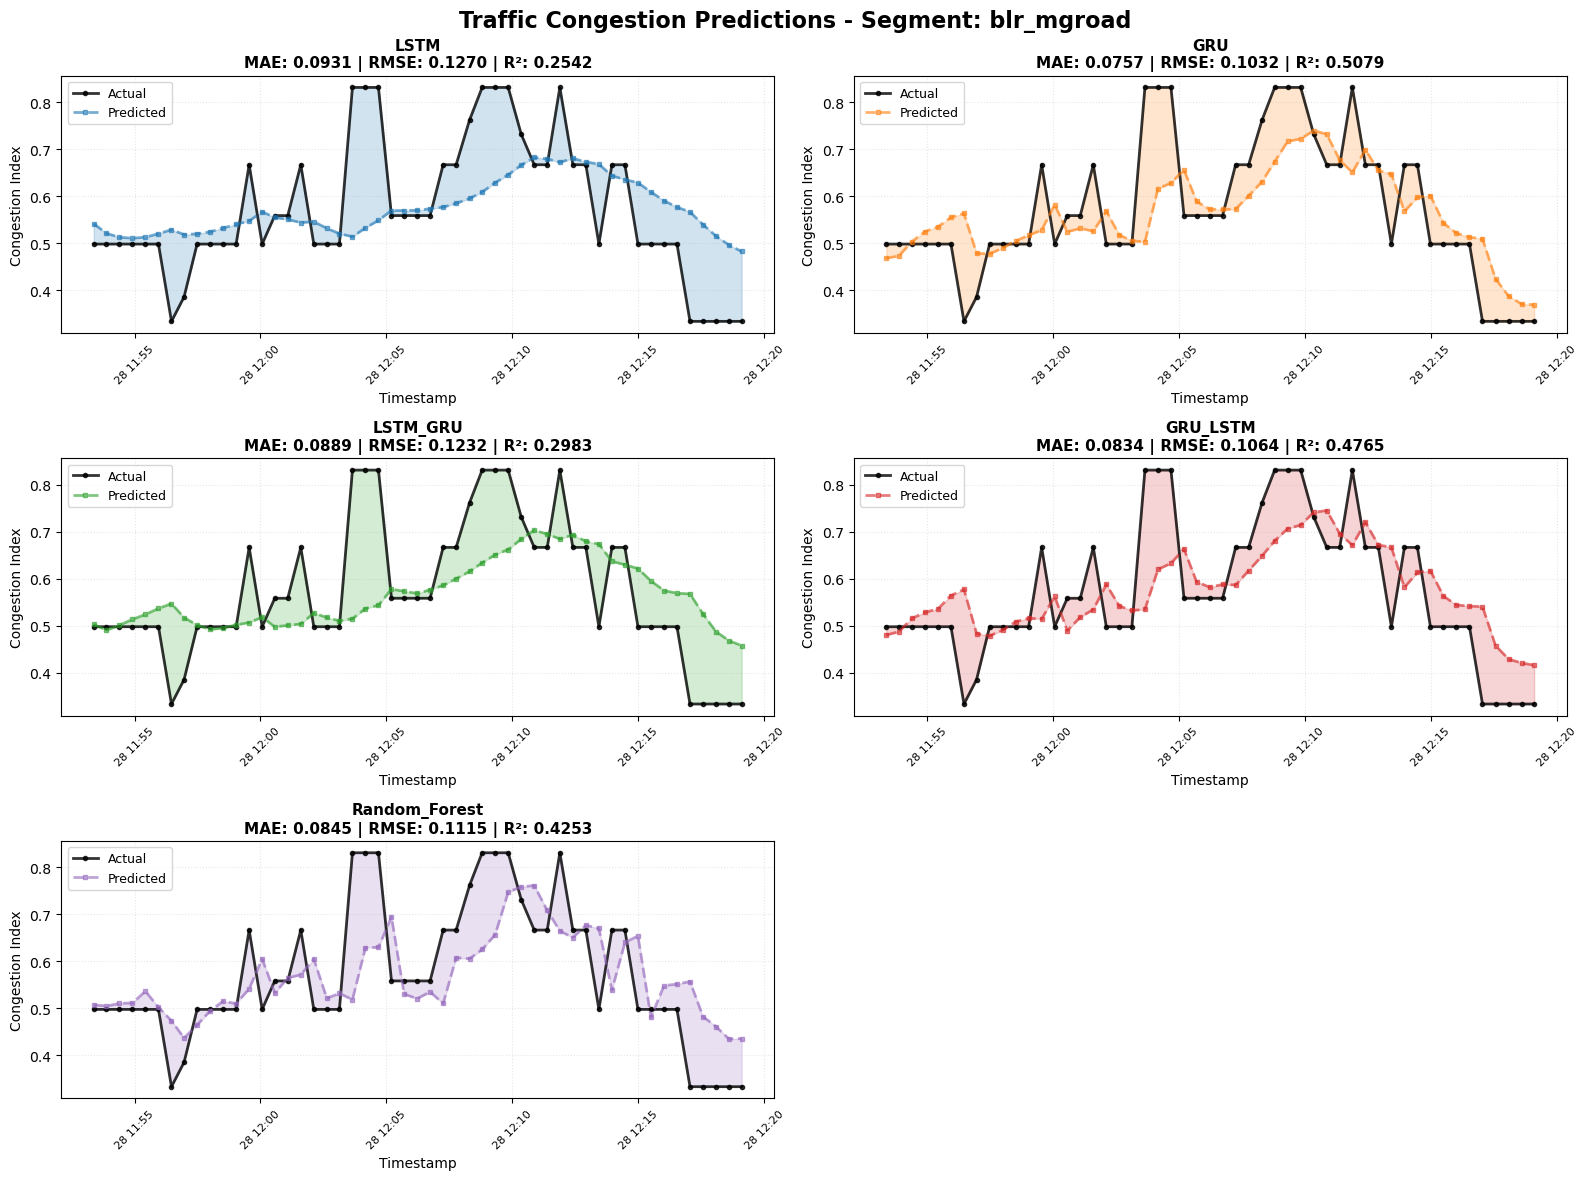


✅ Training complete!

Now making a prediction...
✓ Loaded 1256 records from DataFrame
✓ Filtered to segment_id: blr_mgroad, 314 records

TRAFFIC PREDICTION RESULT

📍 Segment: blr_mgroad
🤖 Model: GRU

⏰ Current Time: 2025-10-28 12:19:06
⏰ Forecast Time: 2025-10-28 12:24:06

📊 Current State:
  Congestion Index: 0.308
  Speed: 18.0 km/h

📈 Prediction:
  Congestion Index: 0.374
  Class: MEDIUM
  Trend: ⬆️ INCREASING (+0.066)



In [40]:
# ==================== EXAMPLE USAGE ====================

if __name__ == '__main__':
    print("""
    ╔══════════════════════════════════════════════════════════════════╗
    ║            REAL-TIME TRAFFIC PREDICTOR (REGRESSION)              ║                                                              ║
    ╚══════════════════════════════════════════════════════════════════╝
    """)
    
    # OPTION 1: Load from directory (YOUR USE CASE)
    parquet_directory = '../data/silver/'  # Change this to your directory
    
    try:
        # Load all parquet files from directory
        df = load_all_parquet_files(parquet_directory)
    except Exception as e:
        print(f'\n⚠️  Could not load from directory: {e}')
        print('Generating sample data instead...\n')
        
        # OPTION 2: Generate sample data (fallback)
        sample_data = []
        segments = ['blr_mgroad', 'blr_silkboard', 'blr_majestic', 'blr_hebball']
        base_time = pd.Timestamp('2025-10-27 09:00:00')
        
        for i in range(100):
            timestamp = base_time + pd.Timedelta(minutes=5*i)
            
            for seg in segments:
                hour = timestamp.hour
                if 7 <= hour <= 9 or 17 <= hour <= 19:
                    speed = np.random.uniform(15, 30)
                    congestion = np.random.uniform(0.3, 0.8)
                else:
                    speed = np.random.uniform(30, 50)
                    congestion = np.random.uniform(0.0, 0.4)
                
                sample_data.append({
                    'segment_id': seg,
                    'timestamp_ist': timestamp,
                    'speed_current_kmph': speed,
                    'speed_freeflow_kmph': 50.0,
                    'congestion_index': congestion
                })
        
        df = pd.DataFrame(sample_data)
        print(f'✓ Created {len(df)} sample records')
    
    # Initialize predictor
    predictor = RealtimeTrafficPredictor(model_path='models/regression/')
    # Make individual predictions first
    predictions_dict = {}
    for model_name in ['LSTM', 'GRU', 'LSTM_GRU', 'GRU_LSTM', 'Random_Forest']:
        try:
            result = predictor.predict_next_interval(df, 'blr_mgroad', model_name)
            predictions_dict[model_name] = result
        except Exception as e:
            print(f"⚠️ Skipped {model_name}: {e}")

    # Now visualize properly
    create_project_visualizations(predictor, df, predictions_dict, segment_id='blr_mgroad')
    
    
    # Try training on sample data
    try:
        print('\nTraining on sample data (blr_mgroad)...')
        print('This will take 2-3 minutes...\n')
        
        results, predictions = predictor.train_all_models(df, segment_id='blr_mgroad')
        
        print('\n✅ Training complete!')
        print('\nNow making a prediction...')
        
        # Make prediction on same data
        result = predictor.predict_next_interval(df, 'blr_mgroad', 'GRU')
        predictor.format_prediction(result)
        
    except Exception as e:
        print(f'\n⚠️  Demo training skipped: {e}')
        print('To train models, provide enough data (at least 50+ records per segment)') 